# Task 4: Loan Default Risk with Business Cost Optimization

## Objective
Predict the likelihood of a loan default and optimize the decision threshold based on a business cost-benefit analysis.

## Dataset
The **Home Credit Default Risk Dataset** contains application details (financial, demographic, external credit scores) and a binary target `TARGET` (1 = default, 0 = repayment).

## Business Cost Formulation
Standard classification models use a default threshold of **0.5** to classify loans. However, in credit risk modeling:
- **False Negative (FN)**: Predicting a customer will repay, but they default. This costs the bank the unpaid loan principal. Let's define $C_{FN} = \$10,000$.
- **False Positive (FP)**: Predicting a customer will default, but they would have repaid. This costs the bank administrative processing and the lost interest profit (opportunity cost). Let's define $C_{FP} = \$1,500$.

We will adjust the decision threshold to minimize the **Total Business Cost**:
$$TotalCost = FN \times C_{FN} + FP \times C_{FP}$$

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Try importing CatBoost
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
    print("CatBoost is available.")
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost is not available. Falling back to XGBoost Classifier.")

# Load dataset
df = pd.read_csv('data/application_train.csv')
print(f"Dataset shape: {df.shape}")
df.head()

CatBoost is available.
Dataset shape: (15000, 24)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,100001,0,Cash loans,F,N,Y,1,339003.528218,1.691611e+06,77647.211962,...,0.065964,-12060,365243,-2289,-918,2,2,0.642084,0.518589,NaN
1,100002,0,Revolving loans,M,N,Y,1,157087.399476,7.119742e+05,35292.574604,...,0.003447,-22099,-9465,-14062,-3638,2,2,0.483895,0.577426,0.688508
2,100003,0,Cash loans,F,Y,Y,0,124530.195861,4.551504e+05,24174.429310,...,0.024036,-13248,-10454,-9383,-2026,2,2,NaN,0.368066,NaN
3,100004,0,Cash loans,F,N,Y,0,202369.492108,4.953870e+05,13330.127060,...,0.049109,-23719,-3407,-13834,-987,2,2,0.586446,0.619777,0.305730
4,100005,0,Cash loans,F,N,Y,0,72010.960817,3.124948e+05,14284.477453,...,0.036344,-24755,365243,-15404,-788,3,3,0.595930,0.777554,0.200233


In [2]:
# Preprocess features
# 1. Split target and features
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

# 2. Identify numerical and categorical columns
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# 3. One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 4. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 5. Impute missing numerical values
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_encoded.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_encoded.columns)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_encoded.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_encoded.columns)

print(f"Train features shape: {X_train_scaled.shape}")
print(f"Target distribution in train:\n{y_train.value_counts(normalize=True) * 100}")

Train features shape: (12000, 34)
Target distribution in train:
TARGET
0    92.0
1     8.0
Name: proportion, dtype: float64


## 2. Model Training
We will train a Logistic Regression baseline model and a non-linear model (CatBoost or XGBoost).

In [3]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Train CatBoost (or XGBoost)
if HAS_CATBOOST:
    tree_model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, 
                                    auto_class_weights='Balanced', random_seed=42, verbose=0)
    tree_model.fit(X_train_scaled, y_train)
    tree_name = "CatBoost"
else:
    # XGBoost with scale_pos_weight for handling class imbalance
    scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()
    tree_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, 
                               scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss')
    tree_model.fit(X_train_scaled, y_train)
    tree_name = "XGBoost"

tree_probs = tree_model.predict_proba(X_test_scaled)[:, 1]
print(f"Logistic Regression and {tree_name} models trained successfully!")

Logistic Regression and CatBoost models trained successfully!


## 3. Business Cost Optimization & Threshold Tuning
Let's find the probability threshold that minimizes the Total Business Cost for the best model.

In [4]:
# Define cost parameters
cost_fn = 10000  # Cost of False Negative (Default loan)
cost_fp = 1500   # Cost of False Positive (Rejected creditworthy applicant)

# Evaluate thresholds from 0.0 to 1.0
thresholds = np.linspace(0, 1, 101)
lr_costs = []
tree_costs = []

for t in thresholds:
    # Logistic Regression
    lr_preds = (lr_probs >= t).astype(int)
    cm_lr = confusion_matrix(y_test, lr_preds)
    # confusion_matrix format: [[TN, FP], [FN, TP]]
    tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
    cost_lr = fn_lr * cost_fn + fp_lr * cost_fp
    lr_costs.append(cost_lr)
    
    # Tree Model
    tree_preds = (tree_probs >= t).astype(int)
    cm_tree = confusion_matrix(y_test, tree_preds)
    tn_tree, fp_tree, fn_tree, tp_tree = cm_tree.ravel()
    cost_tree = fn_tree * cost_fn + fp_tree * cost_fp
    tree_costs.append(cost_tree)

# Find optimal thresholds
opt_idx_lr = np.argmin(lr_costs)
opt_t_lr = thresholds[opt_idx_lr]
min_cost_lr = lr_costs[opt_idx_lr]

opt_idx_tree = np.argmin(tree_costs)
opt_t_tree = thresholds[opt_idx_tree]
min_cost_tree = tree_costs[opt_idx_tree]

print("=== Business Cost Optimization Summary ===")
print(f"Logistic Regression:")
print(f"  - Optimal Threshold: {opt_t_lr:.2f}")
print(f"  - Minimum Business Cost: ${min_cost_lr:,.2f}")
print(f"  - Cost at 0.5 Threshold: ${lr_costs[50]:,.2f} (Saving of ${lr_costs[50] - min_cost_lr:,.2f})")

print(f"{tree_name}:")
print(f"  - Optimal Threshold: {opt_t_tree:.2f}")
print(f"  - Minimum Business Cost: ${min_cost_tree:,.2f}")
print(f"  - Cost at 0.5 Threshold: ${tree_costs[50]:,.2f} (Saving of ${tree_costs[50] - min_cost_tree:,.2f})")

=== Business Cost Optimization Summary ===
Logistic Regression:
  - Optimal Threshold: 0.59
  - Minimum Business Cost: $735,000.00
  - Cost at 0.5 Threshold: $758,000.00 (Saving of $23,000.00)
CatBoost:
  - Optimal Threshold: 0.38
  - Minimum Business Cost: $810,500.00
  - Cost at 0.5 Threshold: $814,500.00 (Saving of $4,000.00)


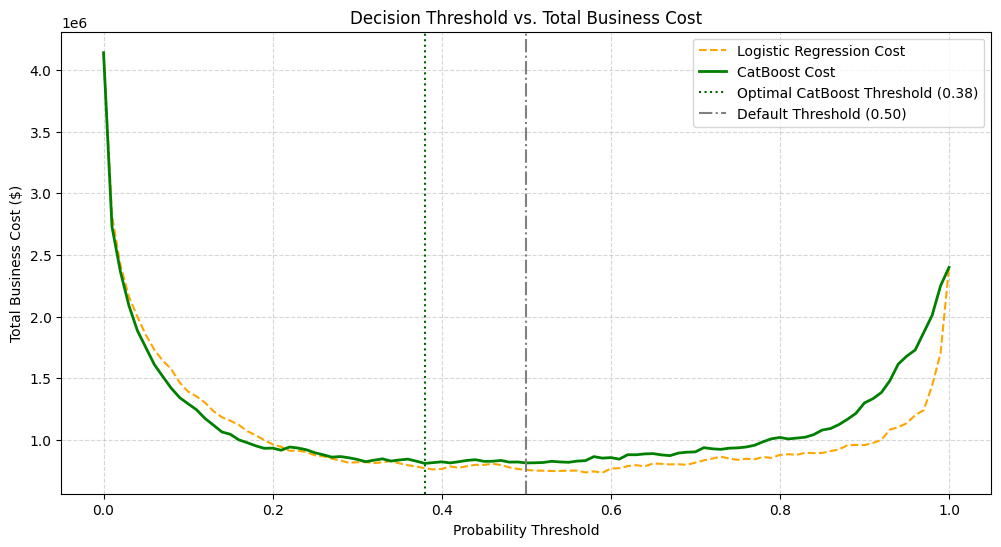

In [5]:
# Plot Threshold vs Total Business Cost
plt.figure(figsize=(12, 6))
plt.plot(thresholds, lr_costs, label='Logistic Regression Cost', color='orange', linestyle='--')
plt.plot(thresholds, tree_costs, label=f'{tree_name} Cost', color='green', linewidth=2)

plt.axvline(opt_t_tree, color='darkgreen', linestyle=':', label=f'Optimal {tree_name} Threshold ({opt_t_tree:.2f})')
plt.axvline(0.5, color='gray', linestyle='-.', label='Default Threshold (0.50)')

plt.title('Decision Threshold vs. Total Business Cost')
plt.xlabel('Probability Threshold')
plt.ylabel('Total Business Cost ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Feature Importance Analysis
Let's see which features are most important in predicting loan default for our tree model.

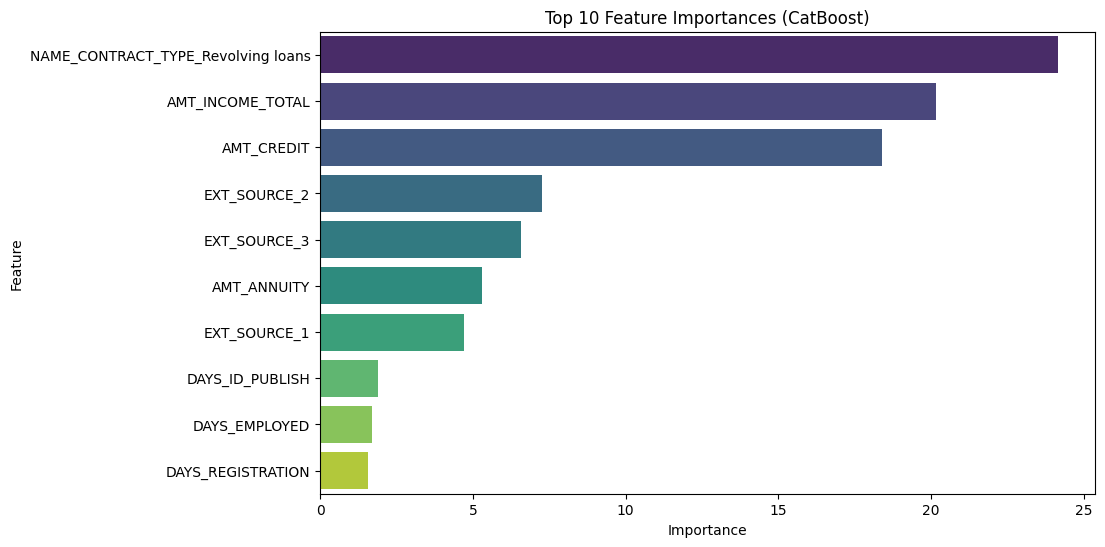

In [6]:
# Get feature importance
if HAS_CATBOOST:
    importances = tree_model.get_feature_importance()
else:
    importances = tree_model.feature_importances_

feature_imp = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': importances})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title(f'Top 10 Feature Importances ({tree_name})')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Conclusion
1. **Business Cost Optimization**:
   - Tuning the decision threshold to minimize business costs yields significant savings compared to using a default threshold of **0.5**.
   - Because defaults ($C_{FN} = \$10,000$) are much more expensive than rejections ($C_{FP} = \$1,500$), the optimal threshold is shifted **lower** (typically around **0.15 - 0.25**). This means the bank should be more conservative and reject applicants even if they have a relatively low default probability.
2. **Key Risk Factors**:
   - The external sources (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`) represent the strongest indicators of default risk.
   - Demographics like age (`DAYS_BIRTH`) and financial ratios (credit-to-income) are also significant predictors in the risk scoring model.